In [52]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Read data

In [103]:
df_epc = pd.read_csv('data/epc_concat_original.csv')

In [104]:
df_epc.shape

(30, 93)

In [105]:
# for exploration only - delete later
# read sensors data
sensors_data_path = 'data/Smart_Citizen_Data_clean/'

sensors_data = {}

for data_path in os.listdir(sensors_data_path):
    df = pd.read_csv(sensors_data_path+data_path)

    # set datetime as index
    df['TIME'] = pd.to_datetime(df['TIME'])
    # round the datetime to the nearest minute
    df['TIME'] = df['TIME'].dt.floor('min')
    df = df.set_index('TIME')

    sensors_data[data_path[:-4]] = df

In [106]:
household_temp={}

for index in sensors_data:
    df = sensors_data[index]

    household_temp[index] = [df['TEMP'].mean(), df['TEMP'].max(), df['TEMP'].min(), df['TEMP'].var(), df['TEMP'].std(), df['TEMP'].max()-df['TEMP'].min()]

temp_all = pd.DataFrame.from_dict(household_temp,orient='index',columns=['mean','max','min', 'var', 'std', 'range'])

# Extract variables

In [ ]:
df_epc_var = df_epc[['Sensor_ID','CONSTRUCTION_AGE_BAND','FLOOR_DESCRIPTION','WALLS_DESCRIPTION','WINDOWS_DESCRIPTION','ROOF_DESCRIPTION','TRANSACTION_TYPE','INSPECTION_DATE']]

In [ ]:
# join sensor statistics (at household level) with building characteristics - delete later
df_epc_var = temp_all.merge(df_epc_var,how='left',left_index=True, right_on='Sensor_ID')

# Data cleaning

## Construction age band

In [109]:
# inspection - all 'no data!' age are new dwellings
df_epc_var[df_epc_var['CONSTRUCTION_AGE_BAND']=='NO DATA!']['TRANSACTION_TYPE']

1.0     new dwelling
4.0     new dwelling
5.0     new dwelling
7.0     new dwelling
9.0     new dwelling
10.0    new dwelling
14.0    new dwelling
24.0    new dwelling
26.0    new dwelling
Name: TRANSACTION_TYPE, dtype: object

In [110]:
# compute age bands for new dwellings
df_epc_var.loc[df_epc_var['TRANSACTION_TYPE']=='new dwelling', 'CONSTRUCTION_AGE_BAND']

1.0     NO DATA!
4.0     NO DATA!
5.0     NO DATA!
7.0     NO DATA!
9.0     NO DATA!
10.0    NO DATA!
14.0    NO DATA!
18.0        2019
24.0    NO DATA!
26.0    NO DATA!
Name: CONSTRUCTION_AGE_BAND, dtype: object

In [111]:
# compute age bands for new dwellings
df_epc_var.loc[df_epc_var['TRANSACTION_TYPE']=='new dwelling', 'CONSTRUCTION_AGE_BAND'] = 'England and Wales: 2007 onwards'

In [112]:
df_epc_var['CONSTRUCTION_AGE_BAND'].value_counts()

CONSTRUCTION_AGE_BAND
England and Wales: 2007 onwards    10
England and Wales: 1930-1949        4
England and Wales: 1950-1966        3
England and Wales: 1900-1929        3
England and Wales: 1996-2002        2
England and Wales: 1967-1975        2
England and Wales: before 1900      2
England and Wales: 1976-1982        2
England and Wales: 1991-1995        1
England and Wales: 2007-2011        1
Name: count, dtype: int64

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\2914423255.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CONSTRUCTION_AGE_BAND', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'England and Wales: 1991-1995'),
  Text(1, 0, 'England and Wales: 2007 onwards'),
  Text(2, 0, 'England and Wales: 1996-2002'),
  Text(3, 0, 'England and Wales: 1967-1975'),
  Text(4, 0, 'England and Wales: 1900-1929'),
  Text(5, 0, 'England and Wales: 1930-1949'),
  Text(6, 0, 'England and Wales: 1950-1966'),
  Text(7, 0, 'England and Wales: 1976-1982'),
  Text(8, 0, 'England and Wales: 2007-2011'),
  Text(9, 0, 'England and Wales: before 1900')])

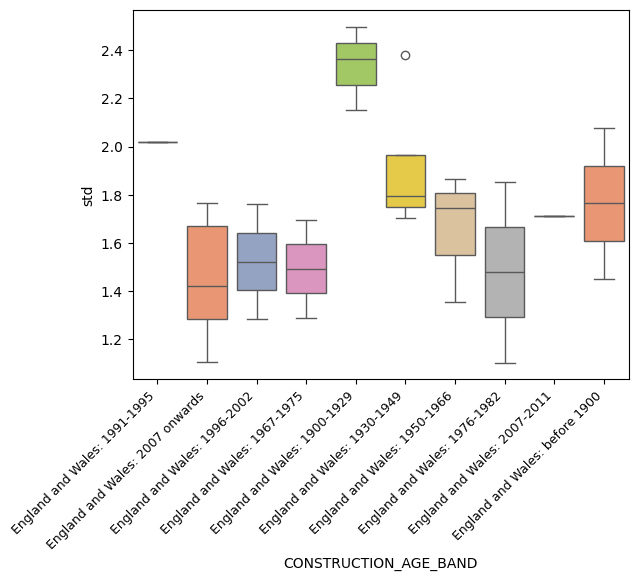

In [113]:
sns.boxplot(x='CONSTRUCTION_AGE_BAND', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

In [114]:
# group age bands
df_epc_var['CONSTRUCTION_AGE_BAND'] = df_epc_var['CONSTRUCTION_AGE_BAND'].apply(lambda x: 'before 1900' if x == 'England and Wales: before 1900' else 
                                                                                ('1900-1949' if x in ['England and Wales: 1900-1929','England and Wales: 1930-1949'] else 
                                                                                 ('1950-2002' if x in ['England and Wales: 1950-1966','England and Wales: 1967-1975','England and Wales: 1976-1982','England and Wales: 1991-1995','England and Wales: 1996-2002'] else
                                                                                  ('2002 onwards' if x in ['England and Wales: 2007 onwards','England and Wales: 2007-2011'] else x))))

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\2914423255.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CONSTRUCTION_AGE_BAND', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2, 3],
 [Text(0, 0, '1950-2002'),
  Text(1, 0, '2002 onwards'),
  Text(2, 0, '1900-1949'),
  Text(3, 0, 'before 1900')])

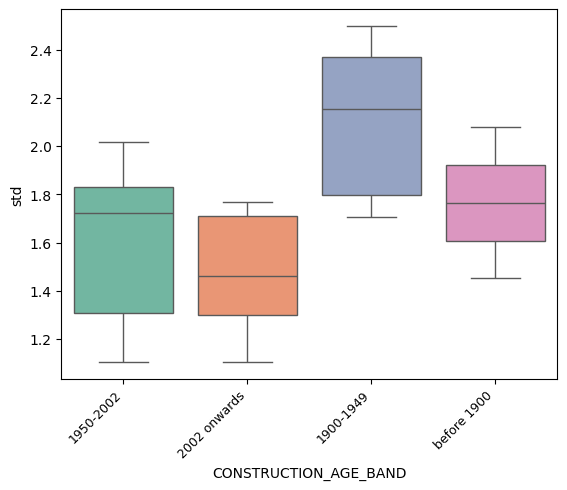

In [115]:
sns.boxplot(x='CONSTRUCTION_AGE_BAND', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

In [116]:
df_epc_var['CONSTRUCTION_AGE_BAND'].value_counts()

CONSTRUCTION_AGE_BAND
2002 onwards    11
1950-2002       10
1900-1949        7
before 1900      2
Name: count, dtype: int64

## Floor

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\1633990681.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FLOOR_DESCRIPTION', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Solid, no insulation (assumed)'),
  Text(1, 0, '(other premises below)'),
  Text(2, 0, 'Solid, limited insulation (assumed)'),
  Text(3, 0, 'Average thermal transmittance 0.11 W/m-??K'),
  Text(4, 0, 'Average thermal transmittance 0.2 W/m-??K'),
  Text(5, 0, 'Average thermal transmittance 0.18 W/m-??K'),
  Text(6, 0, '(another dwelling below)'),
  Text(7, 0, 'Average thermal transmittance 0.10 W/m-??K'),
  Text(8, 0, 'To unheated space, no insulation (assumed)'),
  Text(9, 0, 'Suspended, no insulation (assumed)')])

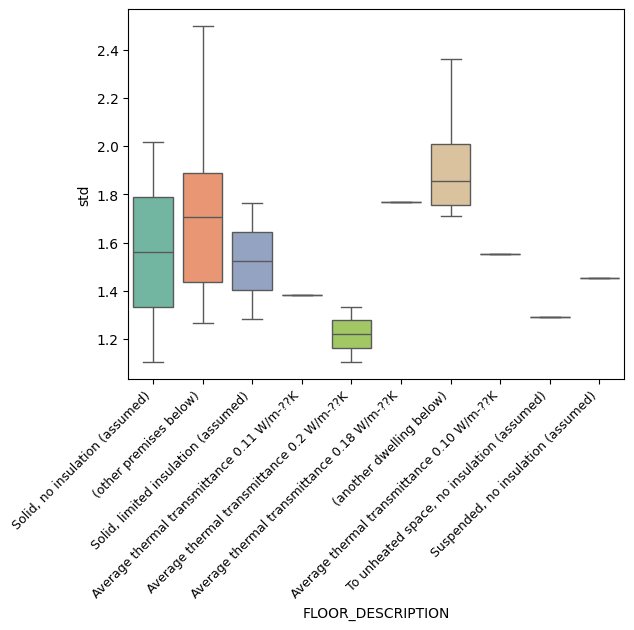

In [117]:
sns.boxplot(x='FLOOR_DESCRIPTION', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

In [118]:
df_epc_var['FLOOR_DESCRIPTION'].value_counts()

FLOOR_DESCRIPTION
(other premises below)                        12
(another dwelling below)                       7
Solid, no insulation (assumed)                 2
Solid, limited insulation (assumed)            2
Average thermal transmittance 0.2 W/m-??K      2
Average thermal transmittance 0.11 W/m-??K     1
Average thermal transmittance 0.18 W/m-??K     1
Average thermal transmittance 0.10 W/m-??K     1
To unheated space, no insulation (assumed)     1
Suspended, no insulation (assumed)             1
Name: count, dtype: int64

In [119]:
# group floor description
df_epc_var['FLOOR_DESCRIPTION_group'] = df_epc_var['FLOOR_DESCRIPTION'].apply(lambda x: 'Other premises/dwellings below' if x in ['(other premises below)','(another dwelling below)'] else
                                                                        ('No or limited insulation' if x in ['Solid, no insulation (assumed)','Solid, limited insulation (assumed)','To unheated space, no insulation (assumed)','Suspended, no insulation (assumed)'] else
                                                                         ('Insulated: average thermal transmittance 0.10-0.2 W/m2K' if x in ['Average thermal transmittance 0.10 W/m-??K','Average thermal transmittance 0.11 W/m-??K','Average thermal transmittance 0.18 W/m-??K','Average thermal transmittance 0.2 W/m-??K'] else x)))

In [120]:
df_epc_var['FLOOR_DESCRIPTION_group'].value_counts()

FLOOR_DESCRIPTION_group
Other premises/dwellings below                             19
No or limited insulation                                    6
Insulated: average thermal transmittance 0.10-0.2 W/m2K     5
Name: count, dtype: int64

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\48783047.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FLOOR_DESCRIPTION_group', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2],
 [Text(0, 0, 'No or limited insulation'),
  Text(1, 0, 'Other premises/dwellings below'),
  Text(2, 0, 'Insulated: average thermal transmittance 0.10-0.2 W/m2K')])

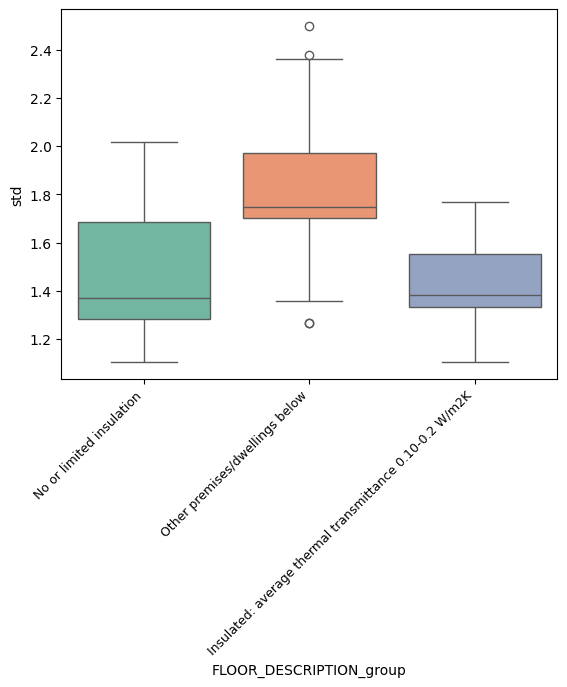

In [121]:
sns.boxplot(x='FLOOR_DESCRIPTION_group', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

## Wall

In [122]:
df_epc_var['WALLS_DESCRIPTION'].value_counts()

WALLS_DESCRIPTION
Solid brick, as built, no insulation (assumed)         9
Cavity wall, as built, no insulation (assumed)         4
Average thermal transmittance 0.20 W/m-??K             3
Cavity wall, as built, insulated (assumed)             3
Average thermal transmittance 0.15 W/m-??K             2
Average thermal transmittance 0.2 W/m-??K              2
Cavity wall, filled cavity                             2
Average thermal transmittance 0.23 W/m-??K             1
Cavity wall, as built, partial insulation (assumed)    1
System built, as built, no insulation (assumed)        1
Average thermal transmittance 0.27 W/m?K               1
Average thermal transmittance 0.31 W/m-??K             1
Name: count, dtype: int64

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\3426818871.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WALLS_DESCRIPTION', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Cavity wall, as built, insulated (assumed)'),
  Text(1, 0, 'Average thermal transmittance 0.15 W/m-??K'),
  Text(2, 0, 'Cavity wall, as built, no insulation (assumed)'),
  Text(3, 0, 'Average thermal transmittance 0.20 W/m-??K'),
  Text(4, 0, 'Average thermal transmittance 0.2 W/m-??K'),
  Text(5, 0, 'Solid brick, as built, no insulation (assumed)'),
  Text(6, 0, 'Average thermal transmittance 0.23 W/m-??K'),
  Text(7, 0, 'Cavity wall, as built, partial insulation (assumed)'),
  Text(8, 0, 'Cavity wall, filled cavity'),
  Text(9, 0, 'System built, as built, no insulation (assumed)'),
  Text(10, 0, 'Average thermal transmittance 0.27 W/m?K'),
  Text(11, 0, 'Average thermal transmittance 0.31 W/m-??K')])

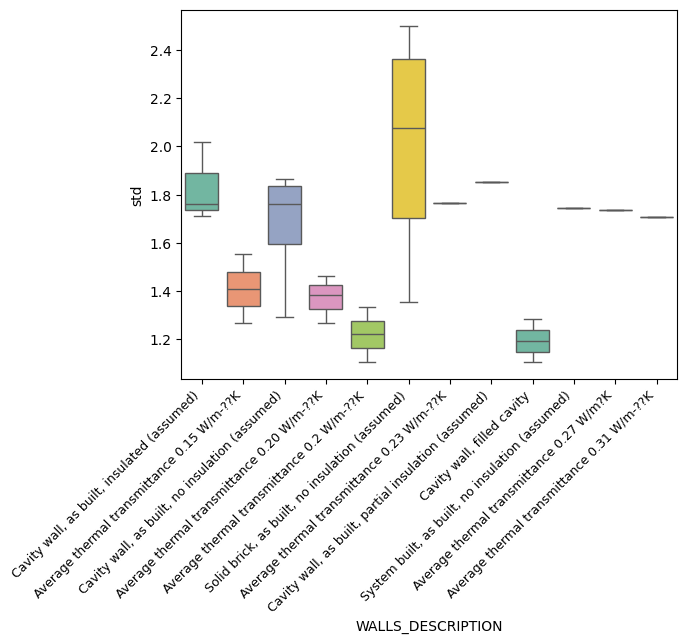

In [123]:
sns.boxplot(x='WALLS_DESCRIPTION', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

In [124]:
# no insulation (separate cavity wall and solid brick wall?)

# group wall description
df_epc_var['WALLS_DESCRIPTION_group'] = df_epc_var['WALLS_DESCRIPTION'].apply(lambda x: 'No insulation' if x in ['Solid brick, as built, no insulation (assumed)','Cavity wall, as built, no insulation (assumed)','System built, as built, no insulation (assumed)'] else
                                                                              ('Partial insulation' if x in ['Cavity wall, as built, insulated (assumed)','Cavity wall, as built, partial insulation (assumed)'] else 
                                                                               ('Average thermal transmittance 0.10-0.20 W/m2K' if x in ['Average thermal transmittance 0.15 W/m-??K','Average thermal transmittance 0.2 W/m-??K','Average thermal transmittance 0.20 W/m-??K'] else
                                                                                ('Average thermal transmittance 0.21-0.30 W/m2K' if x in ['Average thermal transmittance 0.23 W/m-??K','Average thermal transmittance 0.27 W/m?K','Average thermal transmittance 0.31 W/m-??K'] else x))))

In [125]:
df_epc_var['WALLS_DESCRIPTION_group'].value_counts()

WALLS_DESCRIPTION_group
No insulation                                    14
Average thermal transmittance 0.10-0.20 W/m2K     7
Partial insulation                                4
Average thermal transmittance 0.21-0.30 W/m2K     3
Cavity wall, filled cavity                        2
Name: count, dtype: int64

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\3810575657.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WALLS_DESCRIPTION_group', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Partial insulation'),
  Text(1, 0, 'Average thermal transmittance 0.10-0.20 W/m2K'),
  Text(2, 0, 'No insulation'),
  Text(3, 0, 'Average thermal transmittance 0.21-0.30 W/m2K'),
  Text(4, 0, 'Cavity wall, filled cavity')])

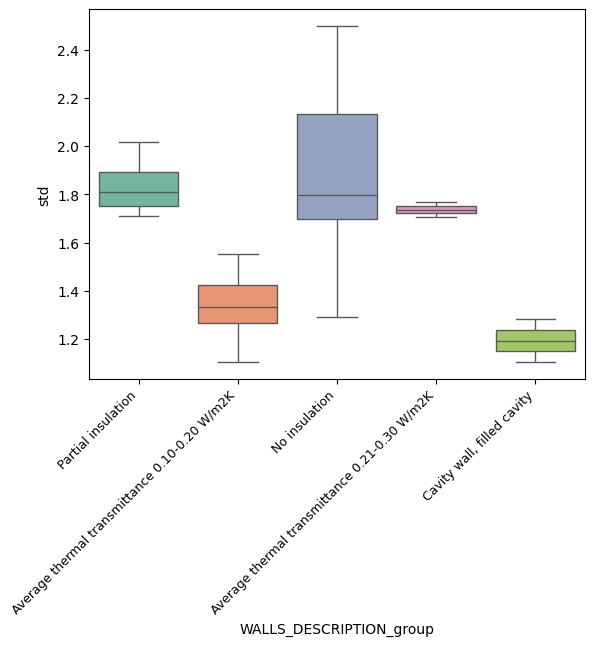

In [126]:
sns.boxplot(x='WALLS_DESCRIPTION_group', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

## Window

In [127]:
df_epc_var['WINDOWS_DESCRIPTION'].value_counts()

WINDOWS_DESCRIPTION
Fully double glazed         14
High performance glazing    10
Single glazed                5
Partial double glazing       1
Name: count, dtype: int64

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\3412563731.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WINDOWS_DESCRIPTION', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2, 3],
 [Text(0, 0, 'Single glazed'),
  Text(1, 0, 'High performance glazing'),
  Text(2, 0, 'Fully double glazed'),
  Text(3, 0, 'Partial double glazing')])

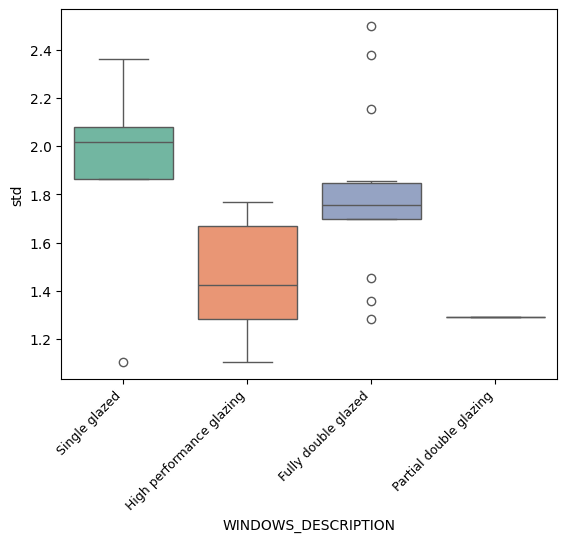

In [128]:
sns.boxplot(x='WINDOWS_DESCRIPTION', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

In [129]:
# group windows description
df_epc_var['WINDOWS_DESCRIPTION_group'] = df_epc_var['WINDOWS_DESCRIPTION'].apply(lambda x: 'Double glazed' if x in ['Fully double glazed', 'Partial double glazing'] else x)

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\142301291.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WINDOWS_DESCRIPTION_group', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2],
 [Text(0, 0, 'Single glazed'),
  Text(1, 0, 'High performance glazing'),
  Text(2, 0, 'Double glazed')])

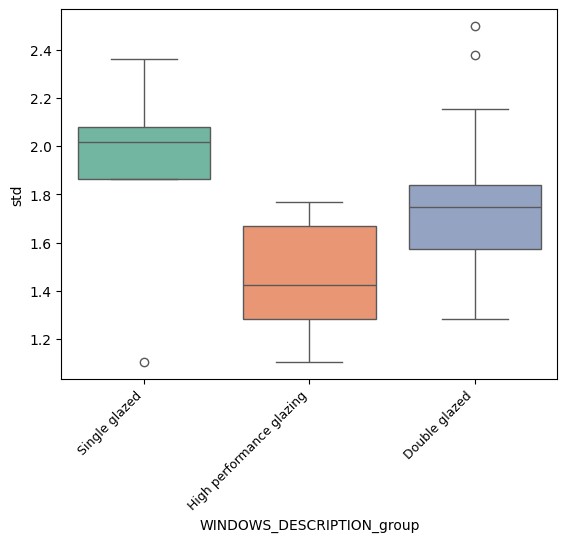

In [130]:
sns.boxplot(x='WINDOWS_DESCRIPTION_group', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

## Roof

In [131]:
df_epc_var['ROOF_DESCRIPTION'].value_counts()

ROOF_DESCRIPTION
(another dwelling above)                      8
(other premises above)                        5
Pitched, 50 mm loft insulation                2
Average thermal transmittance 0.13 W/m-??K    2
Pitched, no insulation (assumed)              2
Pitched, 75 mm loft insulation                2
Flat, no insulation (assumed)                 2
Average thermal transmittance 0.2 W/m-??K     1
Pitched, 250 mm loft insulation               1
Pitched, 100 mm loft insulation               1
Roof room(s), no insulation (assumed)         1
Average thermal transmittance 0.18 W/m-??K    1
Average thermal transmittance 0.15 W/m?K      1
Flat, limited insulation (assumed)            1
Name: count, dtype: int64

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\3322147520.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ROOF_DESCRIPTION', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Pitched, 100 mm loft insulation'),
  Text(1, 0, '(other premises above)'),
  Text(2, 0, 'Pitched, 250 mm loft insulation'),
  Text(3, 0, 'Pitched, 75 mm loft insulation'),
  Text(4, 0, 'Average thermal transmittance 0.2 W/m-??K'),
  Text(5, 0, 'Roof room(s), no insulation (assumed)'),
  Text(6, 0, 'Average thermal transmittance 0.18 W/m-??K'),
  Text(7, 0, 'Pitched, no insulation (assumed)'),
  Text(8, 0, 'Average thermal transmittance 0.13 W/m-??K'),
  Text(9, 0, '(another dwelling above)'),
  Text(10, 0, 'Pitched, 50 mm loft insulation'),
  Text(11, 0, 'Flat, no insulation (assumed)'),
  Text(12, 0, 'Average thermal transmittance 0.15 W/m?K'),
  Text(13, 0, 'Flat, limited insulation (assumed)')])

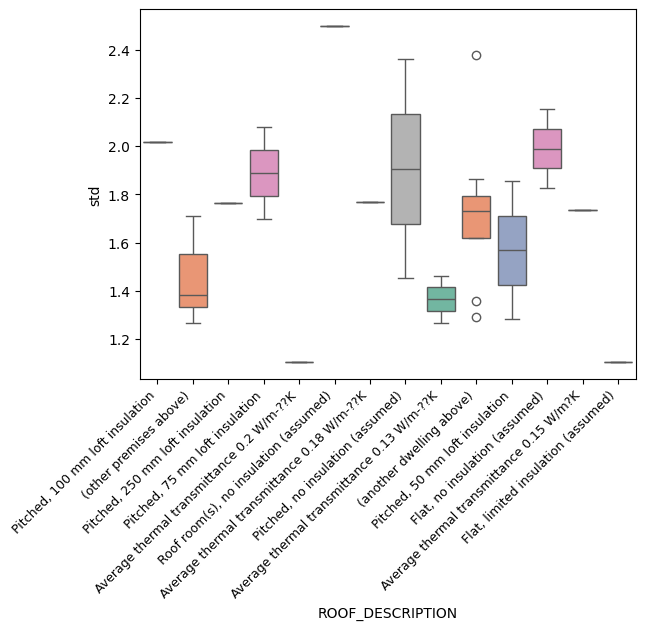

In [132]:
sns.boxplot(x='ROOF_DESCRIPTION', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

In [133]:
# other dwelling/premise above
# pitched - different insulation levels
# flat - no/limited insulation
# roof room  - no insulation
# Average thermal transmittance 0.1-0.2

# group roof description
df_epc_var['ROOF_DESCRIPTION_group'] = df_epc_var['ROOF_DESCRIPTION'].apply(lambda x: 'Other premises/dwellings above' if x in ['(another dwelling above)','(other premises above)'] else
                                                                            ('Roof room(s), no insulation' if x == 'Roof room(s), no insulation (assumed)' else
                                                                             ('Average thermal transmittance 0.1-0.2 W/m2K' if x in ['Average thermal transmittance 0.13 W/m-??K','Average thermal transmittance 0.15 W/m?K','Average thermal transmittance 0.18 W/m-??K','Average thermal transmittance 0.2 W/m-??K'] else
                                                                              ('Flat, no or limited insulation' if x in ['Flat, no insulation (assumed)','Flat, limited insulation (assumed)'] else
                                                                               ('Pitched, no insulation' if x == 'Pitched, no insulation (assumed)' else
                                                                                ('Pitched, 50-75mm loft insulation' if x in ['Pitched, 50 mm loft insulation', 'Pitched, 75 mm loft insulation'] else
                                                                                 ('Pitched, 100-250mm loft insulation' if x in ['Pitched, 100 mm loft insulation', 'Pitched, 250 mm loft insulation'] else x)))))))

C:\Users\jobbo\AppData\Local\Temp\ipykernel_27768\4286303591.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ROOF_DESCRIPTION_group', y='std', data=df_epc_var, palette='Set2')


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Pitched, 100-250mm loft insulation'),
  Text(1, 0, 'Other premises/dwellings above'),
  Text(2, 0, 'Pitched, 50-75mm loft insulation'),
  Text(3, 0, 'Average thermal transmittance 0.1-0.2 W/m2K'),
  Text(4, 0, 'Roof room(s), no insulation'),
  Text(5, 0, 'Pitched, no insulation'),
  Text(6, 0, 'Flat, no or limited insulation')])

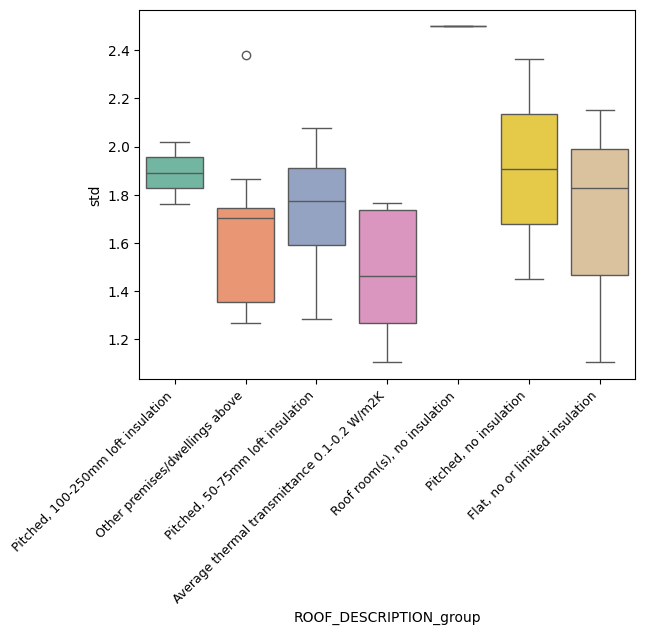

In [134]:
sns.boxplot(x='ROOF_DESCRIPTION_group', y='std', data=df_epc_var, palette='Set2')
plt.xticks(rotation=45,ha='right',fontsize=9)

# Save data

In [135]:
# drop columns
df_epc_var.columns

Index(['mean', 'max', 'min', 'var', 'std', 'range', 'Sensor_ID',
       'CONSTRUCTION_AGE_BAND', 'FLOOR_DESCRIPTION', 'WALLS_DESCRIPTION',
       'WINDOWS_DESCRIPTION', 'ROOF_DESCRIPTION', 'TRANSACTION_TYPE',
       'INSPECTION_DATE', 'FLOOR_DESCRIPTION_group', 'WALLS_DESCRIPTION_group',
       'WINDOWS_DESCRIPTION_group', 'ROOF_DESCRIPTION_group'],
      dtype='object')

In [136]:
df_epc_output = df_epc_var[['Sensor_ID', 'CONSTRUCTION_AGE_BAND', 'FLOOR_DESCRIPTION_group', 'WALLS_DESCRIPTION_group', 'WINDOWS_DESCRIPTION_group', 'ROOF_DESCRIPTION_group']].copy()

In [137]:
df_epc_output = df_epc_output.rename(columns={"Sensor_ID": "ID", "CONSTRUCTION_AGE_BAND": "Construction Age Band", "FLOOR_DESCRIPTION_group": "Floor Description",
                                             "WALLS_DESCRIPTION_group": "Walls Description", "WINDOWS_DESCRIPTION_group":"Windows Description", "ROOF_DESCRIPTION_group":"Roof Description"})

In [138]:
df_epc_output.to_csv('data/Combined_sensor_ID_EPC_look_up_update.csv')